# H₂: Data Efficiency & Feature Importance

1. **Data efficiency curves**: How many training samples does each model need?
2. **Feature importance**: Which features does the RF rely on most?

In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from qiskit.quantum_info import Pauli
from qiskit_ibm_runtime.fake_provider import FakeLimaV2

print('All imports OK')

All imports OK


## 1. Load Data and Build Features

In [2]:
ideal_data = np.load('ideal_data.npy')
noisy_data = np.load('noisy_data.npy')

with open('dataset_meta.json') as f:
    meta = json.load(f)

PAULI_LABELS = meta['pauli_labels']
N_QUBITS = 2

backend = FakeLimaV2()
props = backend.properties()
qubit_props = {}
for q in range(N_QUBITS):
    qubit_props[q] = {
        'T1': props.qubit_property(q, 'T1')[0] * 1e6,
        'T2': props.qubit_property(q, 'T2')[0] * 1e6,
        'readout_error': props.qubit_property(q, 'readout_error')[0],
    }

SYMPLECTIC = {label: np.concatenate([Pauli(label).x.astype(int), Pauli(label).z.astype(int)])
              for label in PAULI_LABELS}
N_2Q, N_SX = 3, 8
ALL_OBS = [1, 2, 3, 4]

def qubit_noise_features(symp):
    feats = []
    for q in range(N_QUBITS):
        active = float(symp[q] == 1 or symp[q + N_QUBITS] == 1)
        feats.extend([
            qubit_props[q]['T1'] * active,
            qubit_props[q]['T2'] * active,
            qubit_props[q]['readout_error'] * active,
        ])
    return feats

def build_features(noisy_subset, ideal_subset, obs_indices):
    rows_X, rows_y = [], []
    for obs_idx in obs_indices:
        label = PAULI_LABELS[obs_idx]
        symp = SYMPLECTIC[label]
        noise_feats = qubit_noise_features(symp)
        for i in range(len(noisy_subset)):
            rows_X.append([noisy_subset[i, obs_idx], *symp,
                           N_2Q, N_SX, *noise_feats])
            rows_y.append(ideal_subset[i, obs_idx])
    return np.array(rows_X, dtype=np.float32), np.array(rows_y, dtype=np.float32)

ideal_test = ideal_data[1800:]
noisy_test = noisy_data[1800:]
X_test, y_test = build_features(noisy_test, ideal_test, ALL_OBS)
baseline_mae = mean_absolute_error(y_test, X_test[:, 0])

print(f'Test set: {X_test.shape[0]} samples, {X_test.shape[1]} features')
print(f'Baseline (unmitigated) MAE: {baseline_mae:.4f}')

Test set: 800 samples, 13 features
Baseline (unmitigated) MAE: 0.0349


## 2. Data Efficiency Curves

In [3]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.BatchNorm1d(hidden), nn.ReLU(),
            nn.Linear(hidden, 1))
    def forward(self, x): return self.net(x)

def train_mlp(X_tr, y_tr, X_te, y_te, n_epochs=300, patience=25):
    scaler = StandardScaler()
    Xs_tr = scaler.fit_transform(X_tr)
    Xs_te = scaler.transform(X_te)

    Xt = torch.tensor(Xs_tr, dtype=torch.float32)
    yt = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)
    Xv = torch.tensor(Xs_te, dtype=torch.float32)

    model = MLP(X_tr.shape[1])
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    crit = nn.HuberLoss()

    best_mae, best_state, no_imp = float('inf'), None, 0
    for epoch in range(n_epochs):
        model.train()
        opt.zero_grad(); crit(model(Xt), yt).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            mae = mean_absolute_error(y_te, model(Xv).numpy().ravel())
        if mae < best_mae - 1e-6:
            best_mae = mae
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
        if no_imp >= patience: break
    return best_mae

train_sizes = [50, 100, 200, 400, 800, 1200, 1800]
rf_maes, mlp_maes = [], []

for n in train_sizes:
    X_tr, y_tr = build_features(noisy_data[:n], ideal_data[:n], ALL_OBS)

    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    rf_mae = mean_absolute_error(y_test, rf.predict(X_test))
    rf_maes.append(rf_mae)

    mlp_mae = train_mlp(X_tr, y_tr, X_test, y_test)
    mlp_maes.append(mlp_mae)

    print(f'  n={n:>5}: RF={rf_mae:.4f}, MLP={mlp_mae:.4f}')

print('Done.')

  n=   50: RF=0.0150, MLP=0.0090
  n=  100: RF=0.0128, MLP=0.0090
  n=  200: RF=0.0116, MLP=0.0098
  n=  400: RF=0.0095, MLP=0.0087
  n=  800: RF=0.0088, MLP=0.0093
  n= 1200: RF=0.0085, MLP=0.0095
  n= 1800: RF=0.0084, MLP=0.0081
Done.


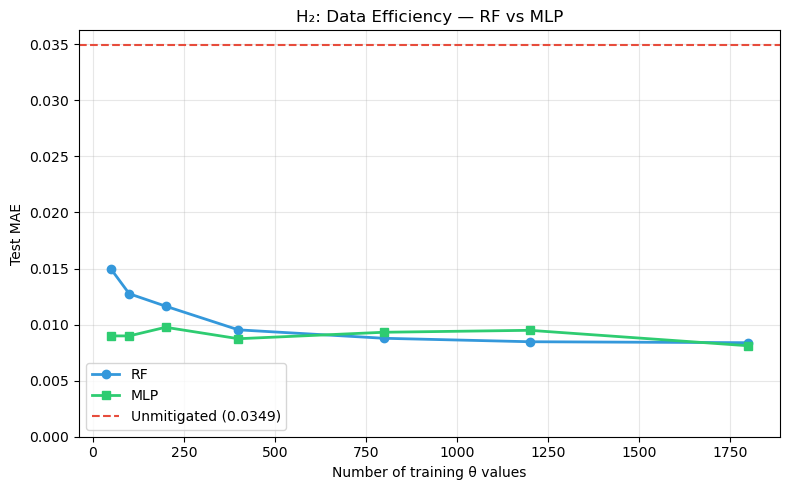

Saved: h2_data_efficiency.png


In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(train_sizes, rf_maes, 'o-', color='#3498db', linewidth=2,
        markersize=6, label='RF')
ax.plot(train_sizes, mlp_maes, 's-', color='#2ecc71', linewidth=2,
        markersize=6, label='MLP')
ax.axhline(baseline_mae, color='#e74c3c', linestyle='--', linewidth=1.5,
           label=f'Unmitigated ({baseline_mae:.4f})')

ax.set_xlabel('Number of training \u03b8 values')
ax.set_ylabel('Test MAE')
ax.set_title('H\u2082: Data Efficiency \u2014 RF vs MLP')
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('h2_data_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: h2_data_efficiency.png')

## 3. Feature Importance

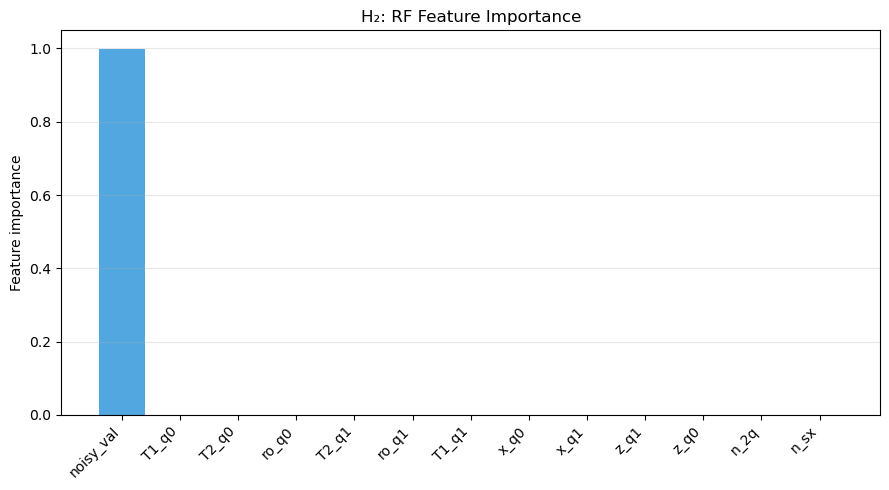


Feature ranking:
  1. noisy_val    0.9995
  2. T1_q0        0.0001
  3. T2_q0        0.0001
  4. ro_q0        0.0001
  5. T2_q1        0.0001
  6. ro_q1        0.0001
  7. T1_q1        0.0001
  8. x_q0         0.0000
  9. x_q1         0.0000
  10. z_q1         0.0000
  11. z_q0         0.0000
  12. n_2q         0.0000
  13. n_sx         0.0000

Saved: h2_feature_importance.png


In [6]:
X_full, y_full = build_features(noisy_data[:1800], ideal_data[:1800], ALL_OBS)
rf_full = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_full.fit(X_full, y_full)

feature_names = [
    'noisy_val',
    'x_q0', 'x_q1', 'z_q0', 'z_q1',
    'n_2q', 'n_sx',
    'T1_q0', 'T2_q0', 'ro_q0',
    'T1_q1', 'T2_q1', 'ro_q1',
]

importances = rf_full.feature_importances_
idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(range(len(importances)), importances[idx], color='#3498db', alpha=0.85)
ax.set_xticks(range(len(importances)))
ax.set_xticklabels([feature_names[i] for i in idx], rotation=45, ha='right')
ax.set_ylabel('Feature importance')
ax.set_title('H\u2082: RF Feature Importance')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('h2_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nFeature ranking:')
for rank, i in enumerate(idx):
    print(f'  {rank+1}. {feature_names[i]:<12} {importances[i]:.4f}')

print('\nSaved: h2_feature_importance.png')